In [4]:
import gdown
import pandas as pd

In [5]:
pip install gdown

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
gdown.download(id="1hr-M44jKh9NaQ_kRQWACGNFxU8oIwEv9", output="distances.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1hr-M44jKh9NaQ_kRQWACGNFxU8oIwEv9
To: /Users/maryam/Downloads/distances.csv
100%|██████████| 6.35k/6.35k [00:00<00:00, 22.8kB/s]


'distances.csv'

### Data provenance
The pairwise city-distance matrix used in this notebook was provided by the course teaching assistant as course material. The original data source and collection methodology were not specified, so this repository does not make a claim about the dataset's original provenance or redistribution license.


# MDS and ISOmap

In [7]:

import numpy as np

import matplotlib.pyplot as plt

from scipy.sparse.csgraph import shortest_path
from scipy.linalg          import eigh
from scipy.spatial         import procrustes
from sklearn.manifold      import Isomap as SKIsomap

# Load distance matrix
df = pd.read_csv("distances.csv", index_col=0)
cities = df.index.tolist()
D = df.values

# Custom Isomap pipeline with classical MDS implemented from scratch

In [8]:
# 1. Classical MDS implemented from scratch
def classical_mds(D, n_components=2):
    """
    Performs Classical (metric) MDS on a full distance matrix D.
    Returns an (n x n_components) embedding.
    """
    n = D.shape[0]
    # Centering matrix
    J = np.eye(n) - np.ones((n, n)) / n
    # Double‐centering of squared distances
    B = -0.5 * J.dot(D**2).dot(J)
    # Eigen‐decomposition
    eigvals, eigvecs = eigh(B)
    # Sort descending
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    # Take the top components
    L = np.diag(np.sqrt(np.clip(eigvals[:n_components], a_min=0, a_max=None)))
    V = eigvecs[:, :n_components]
    return V.dot(L)


In [9]:
# 2. Custom Isomap pipeline
def isomap_scratch(D, n_neighbors=5, n_components=2):
    """
    Given a full distance matrix D, build a k‐NN graph,
    compute geodesic distances via Floyd–Warshall,
    then run classical MDS on the resulting matrix.
    """
    n = D.shape[0]
    # 2.1 Build the k‐nearest‐neighbor graph
    G = np.full((n, n), np.inf)
    np.fill_diagonal(G, 0)
    for i in range(n):
        # find the k nearest neighbours (excluding self at index 0)
        nn = np.argsort(D[i])[: n_neighbors+1]
        for j in nn:
            if i != j:
                G[i, j] = D[i, j]
                G[j, i] = D[j, i]
    # 2.2 Shortest paths = approximate geodesic distances
    geoD = shortest_path(G, directed=False, method='FW')
    if not np.isfinite(geoD).all():
        raise ValueError(
            "The k-NN graph is disconnected. Increase n_neighbors."
        )
    # 2.3 Classical MDS on geodesic distance matrix
    return classical_mds(geoD, n_components=n_components)


In [10]:
Y_scratch = isomap_scratch(D, n_neighbors=5, n_components=2)


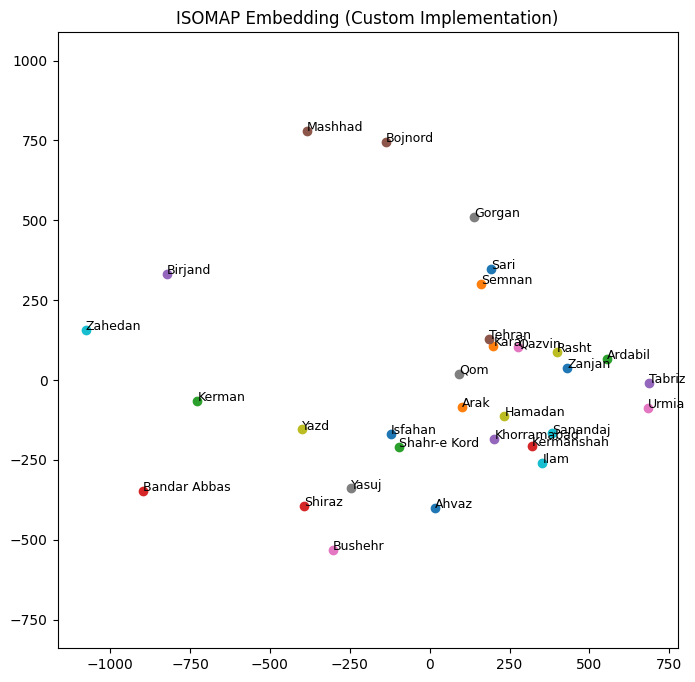

In [11]:
# Plot custom ISOMAP result
plt.figure(figsize=(8, 8))
for i, city in enumerate(cities):
    plt.scatter(Y_scratch[i, 0], Y_scratch[i, 1])
    plt.text(Y_scratch[i, 0], Y_scratch[i, 1], city, fontsize=9)
plt.title('ISOMAP Embedding (Custom Implementation)')
plt.axis('equal')
plt.show()

#optional rotation and reflect

In [12]:
# rotate left:
Y_rot = np.zeros_like(Y_scratch)
Y_rot[:,0] = -Y_scratch[:,1]   # new x = – old y
Y_rot[:,1] =  Y_scratch[:,0]   # new y =   old x

# reflect across vertical axis (flip x):
Y_final = Y_rot.copy()
Y_final[:,0] *= -1


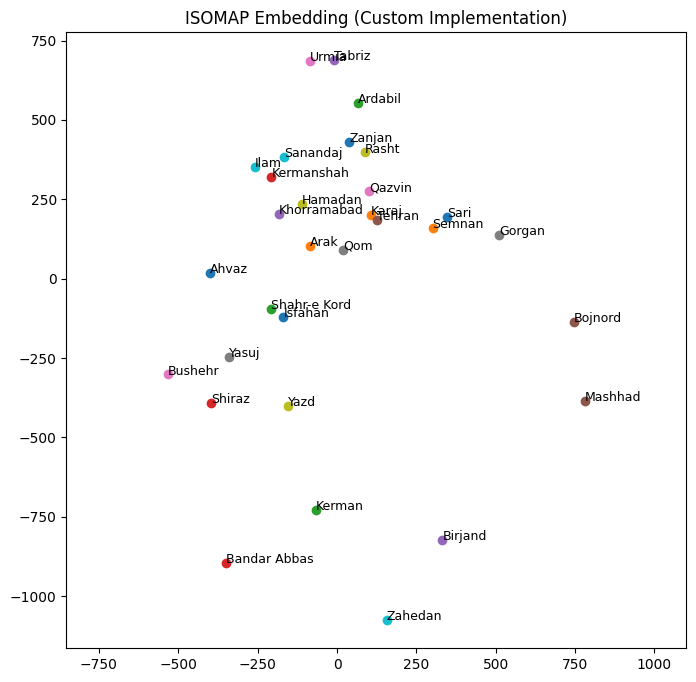

In [13]:
# Plot custom ISOMAP result after rotation and reflect
plt.figure(figsize=(8, 8))
for i, city in enumerate(cities):
    plt.scatter(Y_final[i, 0], Y_final[i, 1])
    plt.text(Y_final[i, 0], Y_final[i, 1], city, fontsize=9)
plt.title('ISOMAP Embedding (Custom Implementation)')
plt.axis('equal')
plt.show()

# 2.scikit-learn ISOMAP

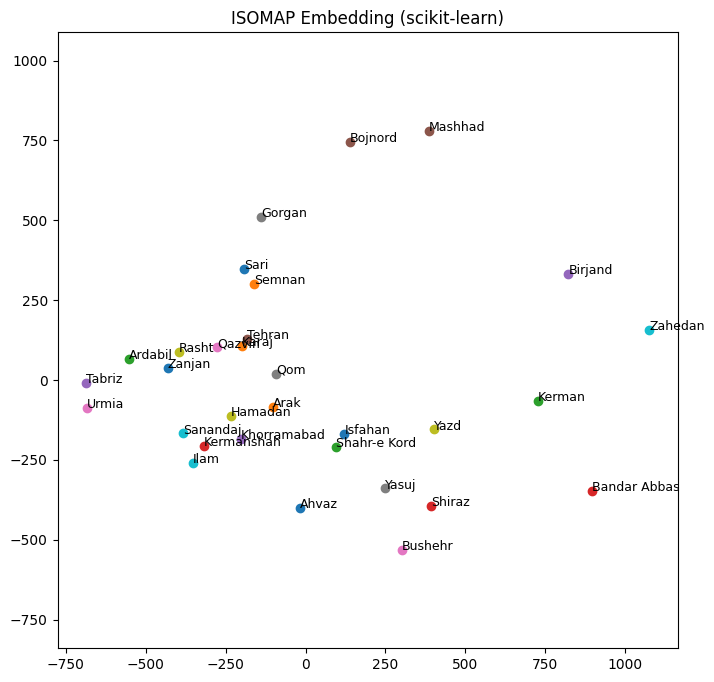

In [14]:
iso = SKIsomap(n_neighbors=5, n_components=2, metric='precomputed')
Y_sklearn = iso.fit_transform(D)



# Plot sklearn ISOMAP result
plt.figure(figsize=(8, 8))
for i, city in enumerate(cities):
    plt.scatter(Y_sklearn[i, 0], Y_sklearn[i, 1])
    plt.text(Y_sklearn[i, 0], Y_sklearn[i, 1], city, fontsize=9)
plt.title('ISOMAP Embedding (scikit-learn)')
plt.axis('equal')
plt.show()

In [15]:

# Align similarly

tmp = Y_sklearn.copy()

Y_sklearn[:, 0] = tmp[:, 1]
Y_sklearn[:, 1] = -tmp[:, 0]


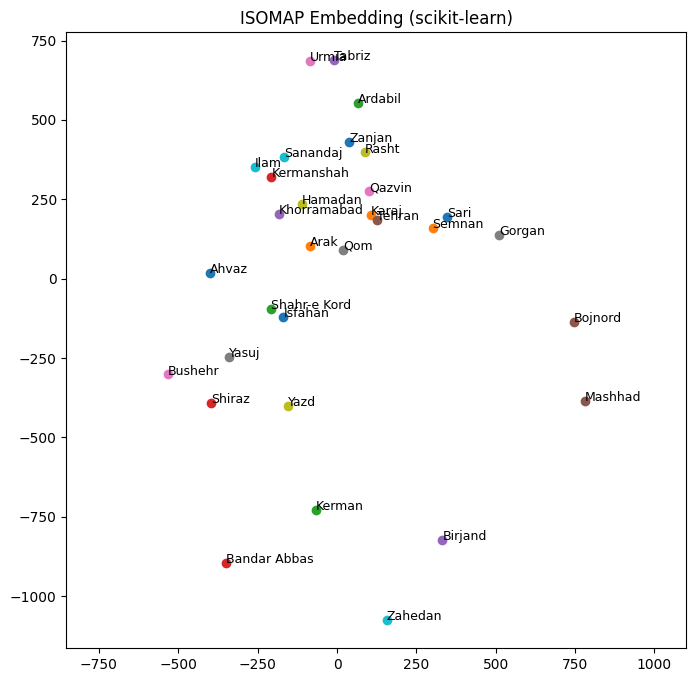

In [16]:
# Plot sklearn ISOMAP result
plt.figure(figsize=(8, 8))
for i, city in enumerate(cities):
    plt.scatter(Y_sklearn[i, 0], Y_sklearn[i, 1])
    plt.text(Y_sklearn[i, 0], Y_sklearn[i, 1], city, fontsize=9)
plt.title('ISOMAP Embedding (scikit-learn)')
plt.axis('equal')
plt.show()

In [17]:
from scipy.spatial import procrustes

# Assume Y_custom and Y_sklearn are (n_points, n_components) numpy arrays
mtx1, mtx2, disparity = procrustes(Y_sklearn, Y_final)

print(f"Procrustes disparity: {disparity:.12e}")

Procrustes disparity: 6.937449804881e-31
